In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
# read CSV with a permissive encoding to avoid UnicodeDecodeError
df = pd.read_csv('Superstore.csv', encoding='latin-1')

In [4]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [5]:
df.head()
df.groupby('Category').size()


Category
Furniture          2121
Office Supplies    6026
Technology         1847
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

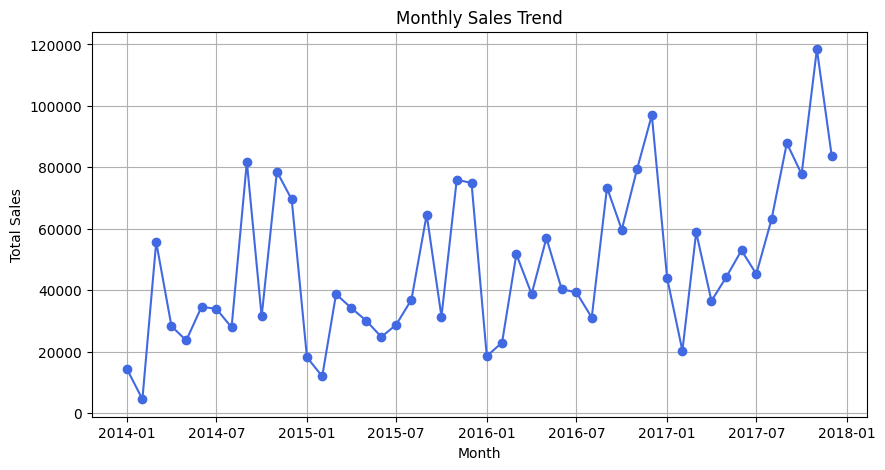

In [8]:
df_monthly = df.groupby(df['Order Date'].dt.to_period('M')).sum(numeric_only=True)
df_monthly.index = df_monthly.index.to_timestamp()

plt.figure(figsize=(10,5))
plt.plot(df_monthly.index, df_monthly['Sales'], marker='o', color='royalblue')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()